In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ts-forecasting/train.parquet
/kaggle/input/ts-forecasting/test.parquet


In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import early_stopping
import matplotlib.pyplot as plt

train = pd.read_parquet("/kaggle/input/ts-forecasting/train.parquet")
test  = pd.read_parquet("/kaggle/input/ts-forecasting/test.parquet")

cutoff = 3400
train_data = train[train["ts_index"] <= cutoff].copy()
valid_data = train[train["ts_index"] > cutoff].copy()

TARGET = "y_target"
DROP_COLS = ["id", "y_target", "weight"]

FEATURES = [col for col in train.columns if col not in DROP_COLS]

X_train = train_data[FEATURES].copy()
y_train = train_data[TARGET]

X_valid = valid_data[FEATURES].copy()
y_valid = valid_data[TARGET]
w_valid = valid_data["weight"]

In [3]:
train.head()

,id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,...,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
0,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,89,29,16.364093,7.464023,5.966933,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.551324,40.982572
1,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__1__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,1,89,53,2.858806,5.050617,15.906651,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.315583,150.075406
2,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__3__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,3,89,51,9.585452,1.076268,9.004147,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.362894,115.953552
3,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__10__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,10,89,44,8.840588,15.034634,4.170780,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.667023,64.573073
4,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__90,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,90,28,2.303825,7.696209,12.896100,...,-0.001622,-0.103809,-0.005135,NaN,-0.174660,2.738606,0.109204,1,-0.437398,41.948761


In [4]:
cat_cols = ["code", "sub_code", "sub_category", "horizon"]

for col in cat_cols:
    X_train[col] = X_train[col].astype("category")
    X_valid[col] = X_valid[col].astype("category")

In [5]:
model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=256,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    categorical_feature=cat_cols,
    callbacks=[early_stopping(200)]
)

print("Best iteration:", model.best_iteration_)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.687136 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 22104
[LightGBM] [Info] Number of data points in the train set: 5000237, number of used features: 91
[LightGBM] [Info] Start training from score -0.666267
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[270]	valid_0's l2: 630.991
Best iteration: 270


In [6]:
preds = model.predict(X_valid)

weighted_mse = np.average((preds - y_valid)**2, weights=w_valid)
weighted_rmse = np.sqrt(weighted_mse)

print("Validation Weighted RMSE:", weighted_rmse)

Validation Weighted RMSE: 0.07905219064640094


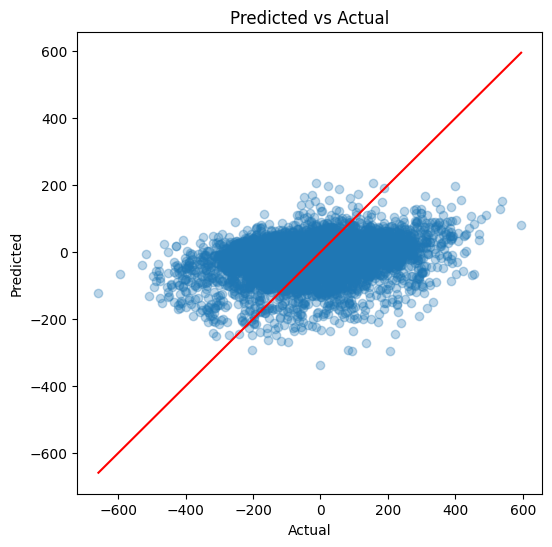

In [7]:
plt.figure(figsize=(6,6))
plt.scatter(y_valid, preds, alpha=0.3)
plt.plot([y_valid.min(), y_valid.max()],
         [y_valid.min(), y_valid.max()],
         color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

**Interpretation:**
* The model can handle mass well
* But, struggles with extreme tails

In [8]:
for col in cat_cols:
    train[col] = train[col].astype("category")
    test[col] = test[col].astype("category")

In [9]:
final_model = lgb.LGBMRegressor(
    n_estimators=model.best_iteration_,
    learning_rate=0.05,
    num_leaves=256,
    random_state=42
)

final_model.fit(
    train[FEATURES],
    train[TARGET],
    categorical_feature=cat_cols
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.745811 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 22114
[LightGBM] [Info] Number of data points in the train set: 5337414, number of used features: 91
[LightGBM] [Info] Start training from score -0.665905


LGBMRegressor(learning_rate=0.05, n_estimators=270, num_leaves=256,
              random_state=42)

In [10]:
test_preds = final_model.predict(test[FEATURES])

submission = test[["id"]].copy()
submission["y_target"] = test_preds

submission.to_csv("submission.csv", index=False)